# 02 — Data Cleaning, Preprocessing & Feature Engineering
**Akeed Restaurant Recommendation System**

This notebook implements every cleaning and feature engineering decision derived from the EDA in `01-exploration.ipynb`.
Three feature tables are produced and saved as Parquet files, ready to feed into the individual recommendation models.

| Output file | Purpose |
|---|---|
| `customers_features.parquet` | One row per customer — demographics + behavioural aggregates + TF-IDF cuisine profile |
| `vendors_features.parquet` | One row per vendor — cleaned attributes + TF-IDF tags + popularity stats |
| `interactions_features.parquet` | One row per (customer × location × vendor) candidate — distances + joined features + binary target |

## 0. Setup & data load

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 100) # Setting pandas to display a N number of columns
pd.set_option('display.max_rows', 10) # Setting pandas to display a N number rows
pd.set_option('display.width', 1000) # Setting pandas dataframe display width to N

# ── Colour palette (matches EDA notebook) ───────────────────────────────────
PAL = {
    "blue":   "#4A90D9",
    "teal":   "#4ECDC4",
    "coral":  "#FF6B6B",
    "gold":   "#FFD166",
    "violet": "#7C6FF7",
    "green":  "#6BCB77",
    "muted":  "#9B9B9B",
}

# ── Oman bounding box ────────────────────────────────────────────────────────
OMAN_LAT = (16.0, 26.5)
OMAN_LON = (51.5, 60.0)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
import kagglehub
path = kagglehub.dataset_download("mrmorj/restaurant-recommendation-challenge")
print("Dataset path:", path)

Dataset path: C:\Users\LAP X\.cache\kagglehub\datasets\mrmorj\restaurant-recommendation-challenge\versions\2


In [3]:
# Load all CSV files
dataframes = {}
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".csv"):
            name = os.path.splitext(f)[0]
            dataframes[name] = pd.read_csv(os.path.join(root, f), low_memory=False)
            print(f"  {name:25s} → {dataframes[name].shape}")

orders_df         = dataframes["orders"]
vendors_df        = dataframes["vendors"].copy()
train_customers_df = dataframes["train_customers"]
train_locations_df = dataframes["train_locations"].copy()
train_full        = dataframes["train_full"]

print("\nAll files loaded ✓")

  orders                    → (135303, 26)
  SampleSubmission (1)      → (1672000, 2)
  test_customers            → (9768, 8)
  test_full                 → (1672000, 72)
  test_locations            → (16720, 5)
  train_customers           → (34674, 8)


ParserError: Error tokenizing data. C error: out of memory

In [ ]:
# Output directory for feature parquet files
OUTPUT_DIR = Path.cwd().parent / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTPUT_DIR)

Output directory: d:\ITI Materials\Projects\restaurant-recommender-system\data\processed


---
## 1. Shared Utilities

In [ ]:
def haversine_series(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance in km (works on NumPy arrays / pandas Series)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [
        np.asarray(lat1, dtype=float), np.asarray(lon1, dtype=float),
        np.asarray(lat2, dtype=float), np.asarray(lon2, dtype=float),
    ])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def apply_oman_bbox(df, lat_col="latitude", lon_col="longitude", label=""):
    """Filter rows whose coordinates fall outside Oman's bounding box."""
    before = len(df)
    mask = (
        df[lat_col].between(*OMAN_LAT) &
        df[lon_col].between(*OMAN_LON)
    )
    df_clean = df[mask].copy()
    removed  = before - len(df_clean)
    if removed:
        print(f"  [{label}] Removed {removed:,} rows outside Oman bbox")
    return df_clean


def plot_before_after(series_before, series_after, col, bins=50, cap_pct=0.99):
    """Side-by-side before/after distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, s, title in zip(axes,
                             [series_before, series_after],
                             [f"{col} — BEFORE", f"{col} — AFTER"]):
        cap = s.quantile(cap_pct) if s.nunique() > 2 else s.max()
        ax.hist(s[s <= cap].dropna(), bins=bins,
                color=PAL["teal"], edgecolor="white", alpha=0.85)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

print("Utilities defined ✓")

Utilities defined ✓


---
## 2. Clean `train_customers`

### Decisions from EDA
| Column | Decision | Reason |
|---|---|---|
| `dob` | **DROP** | 50 %+ null — unreliable |
| `language` | **DROP** | Single value (English) |
| `status` | **DROP** | ~100 % active — zero variance |
| `verified` | **DROP** | ~99 % verified — zero variance |
| `gender` | **FIX** | Inconsistent encoding (M/male/0 etc.) |
| `created_at` | **ENGINEER** | Parse → `account_age_days` |

In [ ]:
customers = train_customers_df.copy()
print("Shape before cleaning:", customers.shape)

# ── 2.1  Drop zero-variance / near-constant columns ──────────────────────────
DROP_COLS = ["dob", "language", "status", "verified"]
customers.drop(columns=[c for c in DROP_COLS if c in customers.columns], inplace=True)
print(f"Dropped {DROP_COLS} → shape: {customers.shape}")

# ── 2.2  Standardise gender ───────────────────────────────────────────────────
GENDER_MAP = {
    "male": "Male", "m": "Male", "1": "Male",
    "female": "Female", "f": "Female", "0": "Female",
}

def clean_gender(g):
    if pd.isna(g):
        return "Unknown"
    return GENDER_MAP.get(str(g).strip().lower(), "Unknown")

customers["gender"] = customers["gender"].apply(clean_gender)
print("\nGender distribution after fix:")
print(customers["gender"].value_counts())

Shape before cleaning: (34674, 8)
Dropped ['dob', 'language', 'status', 'verified'] → shape: (34674, 4)

Gender distribution after fix:
gender
Male       20738
Unknown    12157
Female      1779
Name: count, dtype: int64


In [ ]:
# ── 2.3  Parse timestamps → account age ──────────────────────────────────────
for col in ["created_at", "updated_at"]:
    if col in customers.columns:
        customers[col] = pd.to_datetime(customers[col], errors="coerce")

REF_DATE = customers["created_at"].max()
customers["account_age_days"] = (REF_DATE - customers["created_at"]).dt.days

print(f"Reference date for age: {REF_DATE.date()}")
print(customers["account_age_days"].describe().round(1))

Reference date for age: 2020-03-03
count    34674.0
mean       233.4
std        178.6
min          0.0
25%         73.0
50%        192.0
75%        394.0
max        754.0
Name: account_age_days, dtype: float64


In [ ]:
# ── 2.4  Encode gender numerically ───────────────────────────────────────────
customers["gender_enc"] = customers["gender"].map({"Male": 0, "Female": 1, "Unknown": -1})

# Rename for clean join keys
customers.rename(columns={"akeed_customer_id": "customer_id"}, inplace=True)

print("\nCleaned customers table:")
print(customers.shape)
customers.head(3)


Cleaned customers table:
(34674, 6)


,customer_id,gender,created_at,updated_at,account_age_days,gender_enc
0,TCHWPBT,Male,2018-02-07 19:16:23,2018-02-07 19:16:23,754,0
1,ZGFSYCZ,Male,2018-02-09 12:04:42,2018-02-09 12:04:41,753,0
2,S2ALZFL,Male,2018-03-14 18:31:43,2018-03-14 18:31:42,719,0


---
## 3. Clean `train_locations`

### Decisions from EDA
- `location_type` → 45 % null: fill with `"Unknown"` (missingness is informative)
- Derive `location_type_enc` (ordinal) and `n_saved_locations` per customer

In [ ]:
locations = train_locations_df.copy()
print("Shape before cleaning:", locations.shape)

# ── 3.1  Coerce lat/lon to numeric ────────────────────────────────────────────
locations["latitude"]  = pd.to_numeric(locations["latitude"],  errors="coerce")
locations["longitude"] = pd.to_numeric(locations["longitude"], errors="coerce")
locations.dropna(subset=["latitude", "longitude"], inplace=True)

# ── 3.2  Oman bbox filter ─────────────────────────────────────────────────────
# locations = apply_oman_bbox(locations, label="locations")

# ── 3.3  Fill missing location_type ──────────────────────────────────────────
locations["location_type"] = locations["location_type"].fillna("Unknown")
print("\nlocation_type distribution:")
print(locations["location_type"].value_counts())

Shape before cleaning: (59503, 5)

location_type distribution:
location_type
Unknown    27205
Home       19702
Work        6441
Other       6149
Name: count, dtype: int64


In [ ]:
# ── 3.4  Deduplicate GPS drift ────────────────────────────────────────────────
before = len(locations)
locations["latitude"]  = locations["latitude"].round(4)
locations["longitude"] = locations["longitude"].round(4)
locations.drop_duplicates(subset=["customer_id", "latitude", "longitude"], inplace=True)
print(f"GPS dedup removed: {before - len(locations):,} rows → {len(locations):,} remain")

# ── 3.5  Ordinal encode location_type ────────────────────────────────────────
LOC_TYPE_MAP = {"Home": 0, "Work": 1, "Other": 2, "Unknown": 3}
locations["location_type_enc"] = locations["location_type"].map(LOC_TYPE_MAP)

# ── 3.6  n_saved_locations per customer ──────────────────────────────────────
n_locs = (locations.groupby("customer_id")
          .size()
          .reset_index(name="n_saved_locations"))
locations = locations.merge(n_locs, on="customer_id", how="left")

# ── 3.7  has_work_address flag ────────────────────────────────────────────────
has_work = (locations[locations["location_type"] == "Work"]
            .groupby("customer_id")["location_type"]
            .any()
            .reset_index()
            .rename(columns={"location_type": "has_work_address"}))
has_work["has_work_address"] = has_work["has_work_address"].astype(int)
locations = locations.merge(has_work, on="customer_id", how="left")
locations["has_work_address"] = locations["has_work_address"].fillna(0).astype(int)

print("\nCleaned locations table:")
print(locations.shape)
locations.head(3)

GPS dedup removed: 0 rows → 59,497 remain

Cleaned locations table:
(59497, 8)


,customer_id,location_number,location_type,latitude,longitude,location_type_enc,n_saved_locations,has_work_address
0,02SFNJH,0,Unknown,1.6824,-78.7897,3,3,0
1,02SFNJH,1,Unknown,1.6791,0.7668,3,3,0
2,02SFNJH,2,Unknown,-0.4986,0.6612,3,3,0


---
## 4. Clean `vendors`

### Decisions from EDA
| Column | Decision | Reason |
|---|---|---|
| `vendor_category_en` | **DROP** | Redundant with `vendor_category_id` |
| `country_id`, `language`, `device_type` | **DROP** | Single value — zero variance |
| `vendor_rating` | **FIX** | Clip [0,5]; impute mean; flag imputed rows |
| `serving_distance` | **FIX** | Cap at 50 km (75th pct = 9,416 km is corrupted) |
| `prepration_time` | **FIX** | Clip [0, 120] min; impute category median |
| `vendor_tag_name` | **RE-ENGINEER** | Replace naive substring one-hot with TF-IDF |
| `vendor_category_id` | **ENGINEER** | One-hot dummies |

In [ ]:
vendors_df["display_orders"].unique()

array([1])

In [ ]:
vendors = vendors_df.copy()
print("Shape before cleaning:", vendors.shape)

# ── 4.1  Drop zero-variance / redundant columns ───────────────────────────────
DROP_VENDOR = ["vendor_category_en", 
               'country_id','city_id', 
               "language", "device_type", "display_orders", 
               "one_click_vendor", "commission", 
               "is_akeed_delivering", "open_close_flags",
               ]
vendors.drop(columns=[c for c in DROP_VENDOR if c in vendors.columns], inplace=True)
print(f"Dropped: {DROP_VENDOR}")

# ── 4.2  Coerce all numeric columns ──────────────────────────────────────────
NUMERIC_COLS = [
    "latitude", "longitude", "vendor_rating", "serving_distance",
    "delivery_charge", "prepration_time", "discount_percentage", "rank",
    "is_open"
    ]
for col in NUMERIC_COLS:
    if col in vendors.columns:
        vendors[col] = pd.to_numeric(vendors[col], errors="coerce")

# ── 4.3  Oman bbox filter for vendor coordinates ──────────────────────────────
# vendors = apply_oman_bbox(vendors, label="vendors")

print(f"Shape after type fixes & bbox: {vendors.shape}")

Shape before cleaning: (100, 59)
Dropped: ['vendor_category_en', 'country_id', 'city_id', 'language', 'device_type', 'display_orders', 'one_click_vendor', 'commission', 'is_akeed_delivering', 'open_close_flags']
Shape after type fixes & bbox: (100, 49)


serving_distance before cap:
 count    100.00
mean      11.75
std        4.11
min        2.00
25%        8.00
50%       15.00
75%       15.00
max       15.00
Name: serving_distance, dtype: float64


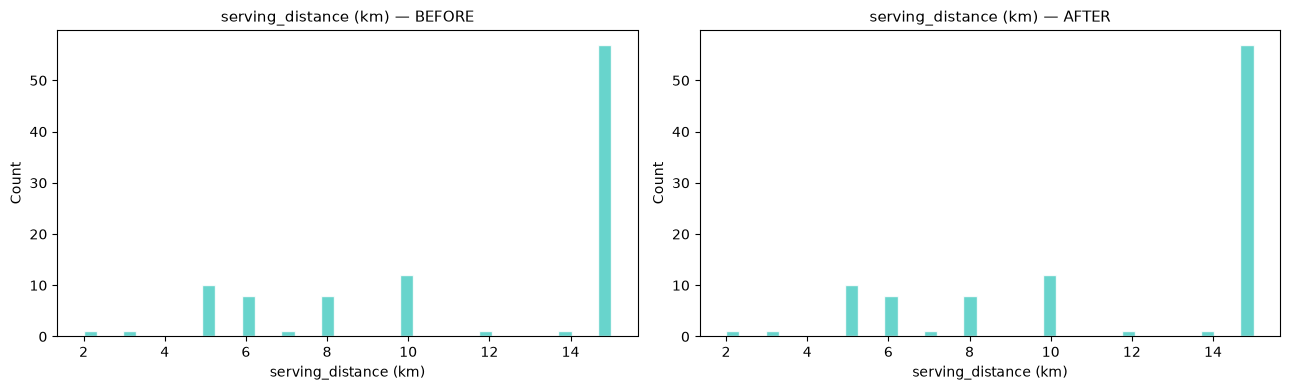

serving_distance after cap:
 count    100.00
mean      11.75
std        4.11
min        2.00
25%        8.00
50%       15.00
75%       15.00
max       15.00
Name: serving_distance, dtype: float64


In [ ]:
# ── 4.4  serving_distance — cap at 50 km ─────────────────────────────────────
SD_CAP = 50.0
print("serving_distance before cap:\n", vendors["serving_distance"].describe().round(2))

plot_before_after(vendors["serving_distance"], vendors["serving_distance"].clip(upper=SD_CAP),
                  col="serving_distance (km)", bins=40)

vendors["serving_distance"] = vendors["serving_distance"].clip(upper=SD_CAP)
print("serving_distance after cap:\n", vendors["serving_distance"].describe().round(2))

In [ ]:
# ── 4.5  vendor_rating — clip [0,5] + mean imputation ────────────────────────
vendors["vendor_rating"] = vendors["vendor_rating"].clip(0, 5)
rating_mean = vendors["vendor_rating"].mean()
vendors["vendor_rating_imputed"] = vendors["vendor_rating"].isna().astype(int)
vendors["vendor_rating"] = vendors["vendor_rating"].fillna(rating_mean)

print(f"Rating mean used for imputation: {rating_mean:.3f}")
print(f"Rows imputed: {vendors['vendor_rating_imputed'].sum()}")

Rating mean used for imputation: 4.350
Rows imputed: 0


In [ ]:
# ── 4.6  prepration_time — clip [0, 120] min + category-median imputation ────
vendors["prepration_time"] = vendors["prepration_time"].clip(lower=0, upper=120)

# Use category median (more precise than global median)
if "vendor_category_id" in vendors.columns:
    cat_median = vendors.groupby("vendor_category_id")["prepration_time"].transform("median")
    vendors["prepration_time"] = vendors["prepration_time"].fillna(cat_median)

global_prep_median = vendors["prepration_time"].median()
vendors["prepration_time"] = vendors["prepration_time"].fillna(global_prep_median)
print(f"prepration_time: {vendors['prepration_time'].describe().round(2).to_dict()}")

prepration_time: {'count': 100.0, 'mean': 14.03, 'std': 4.32, 'min': 5.0, '25%': 10.0, '50%': 15.0, '75%': 15.0, 'max': 45.0}


In [ ]:
# ── 4.7  vendor_tag_name — TF-IDF encoding (replaces naive substring one-hot) ─
#
# WHY: The original encoding used  `if category in x.lower()` which causes tag
# pollution — "pizza" matches "pepperoni pizza", "non-pizza", etc.
# TF-IDF with proper comma-splitting is correct and gives richer weights.

vendors["vendor_tag_name"] = vendors["vendor_tag_name"].fillna("unknown")

# Normalise: lowercase → strip whitespace → comma-split → underscore join tokens
vendors["tags_clean"] = (
    vendors["vendor_tag_name"]
    .str.lower()
    .str.replace(r"[^a-z,\s]", "", regex=True)
    .str.split(",")
    .apply(lambda tags: " ".join(t.strip().replace(" ", "_") for t in tags if t.strip()))
)

tfidf = TfidfVectorizer(max_features=50, min_df=2)
tag_matrix = tfidf.fit_transform(vendors["tags_clean"])

tag_cols = [f"tag_{t}" for t in tfidf.get_feature_names_out()]
tag_df   = pd.DataFrame(tag_matrix.toarray(), columns=tag_cols, index=vendors.index)

vendors = pd.concat([vendors.reset_index(drop=True), tag_df.reset_index(drop=True)], axis=1)

print(f"TF-IDF tag features added: {len(tag_cols)}")
print("\nTop 10 tags by average TF-IDF weight:")
print(tag_df.mean().sort_values(ascending=False).head(10).round(4).to_string())

TF-IDF tag features added: 46

Top 10 tags by average TF-IDF weight:
tag_burgers          0.1378
tag_sandwiches       0.1370
tag_desserts         0.1289
tag_salads           0.1091
tag_american         0.1007
tag_free_delivery    0.0900
tag_breakfast        0.0857
tag_fries            0.0832
tag_fresh_juices     0.0740
tag_pasta            0.0686


In [ ]:
# ── 4.8  vendor_category_id — one-hot dummies ────────────────────────────────
if "vendor_category_id" in vendors.columns:
    cat_dummies = pd.get_dummies(vendors["vendor_category_id"].astype(str),
                                  prefix="vcat", dtype=int)
    vendors = pd.concat([vendors.reset_index(drop=True),
                         cat_dummies.reset_index(drop=True)], axis=1)
    print(f"Category dummies added: {cat_dummies.shape[1]} columns")

Category dummies added: 2 columns


In [ ]:
# ── 4.9  MinMax normalise key numeric columns ─────────────────────────────────
NORM_COLS = ["delivery_charge", "prepration_time", "vendor_rating", "serving_distance"]
scaler = MinMaxScaler()
for col in NORM_COLS:
    if col in vendors.columns:
        vendors[f"{col}_norm"] = scaler.fit_transform(vendors[[col]])

print("Normalised columns added: ", [f"{c}_norm" for c in NORM_COLS])
print("\nVendors clean shape:", vendors.shape)
vendors.head(3)

Normalised columns added:  ['delivery_charge_norm', 'prepration_time_norm', 'vendor_rating_norm', 'serving_distance_norm']

Vendors clean shape: (100, 103)


,id,authentication_id,latitude,longitude,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,discount_percentage,status,verified,rank,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,friday_from_time1,friday_to_time1,friday_from_time2,friday_to_time2,saturday_from_time1,saturday_to_time1,saturday_from_time2,saturday_to_time2,primary_tags,vendor_tag,vendor_tag_name,created_at,updated_at,vendor_rating_imputed,...,tag_asian,tag_biryani,tag_breakfast,tag_burgers,tag_cafe,tag_cakes,tag_coffee,tag_crepes,tag_desserts,tag_donuts,tag_free_delivery,tag_fresh_juices,tag_fries,tag_grills,tag_healthy_food,tag_hot_chocolate,tag_hot_dogs,tag_ice_creams,tag_indian,tag_italian,tag_japanese,tag_kebabs,tag_kids_meal,tag_lebanese,tag_mexican,tag_milkshakes,tag_mishkak,tag_mojitos,tag_omani,tag_pancakes,tag_pasta,tag_pizzas,tag_rice,tag_rolls,tag_salads,tag_sandwiches,tag_shawarma,tag_smoothies,tag_soups,tag_steaks,tag_sweets,tag_thai,tag_unknown,tag_waffles,vcat_2.0,vcat_3.0,delivery_charge_norm,prepration_time_norm,vendor_rating_norm,serving_distance_norm
0,4,118597.0,-0.588596,0.754434,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,1.0,1,11,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,"{""primary_tags"":""4""}","2,4,5,8,91,22,12,24,16,23","Arabic,Breakfast,Burgers,Desserts,Free Deliver...",2018-01-30 14:42:04,2020-04-07 15:12:43,0,...,0.0,0.0,0.283167,0.224708,0.0,0.000000,0.0,0.000000,0.213708,0.0,0.283167,0.0,0.0,0.369901,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.473356,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.246831,0.219080,0.369901,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,0,0.0,0.250,0.7500,0.307692
1,13,118608.0,-0.471654,0.744470,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,1.0,1,11,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,"{""primary_tags"":""7""}","4,41,51,34,27,15,24,16,28","Breakfast,Cakes,Crepes,Italian,Pasta,Pizzas,Sa...",2018-05-03 12:32:06,2020-04-05 20:46:03,0,...,0.0,0.0,0.250661,0.000000,0.0,0.419017,0.0,0.442359,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.419017,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.291003,0.357532,0.0,0.0,0.218496,0.193931,0.000000,0.0,0.304096,0.0,0.0,0.0,0.0,0.0,1,0,1.0,0.225,0.9375,0.230769
2,20,118616.0,-0.407527,0.643681,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,1.0,1,1,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,"{""primary_tags"":""71""}","4,8,91,10","Breakfast,Desserts,Free Delivery,Indian",2018-05-04 22:28:22,2020-04-07 16:35:55,0,...,0.0,0.0,0.478245,0.000000,0.0,0.000000,0.0,0.000000,0.360934,0.0,0.478245,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.642098,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,0,0.0,0.350,0.8125,0.461538


---
## 5. Clean `orders`

### Decisions from EDA
- Drop exact duplicate rows
- Remove rows with `grand_total ≤ 0` (data entry errors / cancellations)
- Remove orphan `customer_id` and `vendor_id` rows (no feature context)
- Parse timestamps → `order_hour`, `order_dow` (temporal features)
- Collapse to binary interaction matrix (one row per customer-vendor pair)
- Compute `order_freq` (confidence weight for implicit ALS)

In [ ]:
orders = orders_df.copy()
print("Orders shape before cleaning:", orders.shape)

# ── 5.1  Coerce numeric columns ────────────────────────────────────────────────
orders["grand_total"] = pd.to_numeric(orders["grand_total"], errors="coerce")
orders["item_count"]  = pd.to_numeric(orders["item_count"],  errors="coerce")

# ── 5.2  Drop exact duplicate rows ────────────────────────────────────────────
before = len(orders)
orders.drop_duplicates(inplace=True)
print(f"Duplicate rows removed: {before - len(orders):,}")

# ── 5.3  Remove invalid grand_total ──────────────────────────────────────────
before = len(orders)
orders = orders[orders["grand_total"].isna() | (orders["grand_total"] > 0)]
print(f"Removed {before - len(orders):,} rows with grand_total ≤ 0")

# ── 5.4  Cap grand_total at 99th pct (feature use, not filtering) ─────────────
GT_CAP = orders["grand_total"].quantile(0.99)
orders["grand_total_capped"] = orders["grand_total"].clip(upper=GT_CAP)
print(f"grand_total capped at 99th pct: {GT_CAP:.2f} OMR")

Orders shape before cleaning: (135303, 26)
Duplicate rows removed: 0
Removed 683 rows with grand_total ≤ 0
grand_total capped at 99th pct: 63.30 OMR


In [ ]:
orders_customers = set(orders["customer_id"].unique())
customer_master  = set(customers["customer_id"].unique())

orphans = orders_customers - customer_master

print("Unique orphan customers:", len(orphans))

orphan_orders = orders[
    orders["customer_id"].isin(orphans)
]

print("Orders from orphan customers:", len(orphan_orders))

Unique orphan customers: 658
Orders from orphan customers: 3261


In [ ]:
normal_orders = orders[
    orders["customer_id"].isin(customer_master)
]

orphan_orders = orders[
    orders["customer_id"].isin(orphans)
]

print(normal_orders["grand_total"].describe())
print("\n")
print(orphan_orders["grand_total"].describe())
print("\n\n")

print(normal_orders["item_count"].describe())
print(orphan_orders["item_count"].describe())
print("\n\n")

print(normal_orders["vendor_id"].nunique())
print(orphan_orders["vendor_id"].nunique())
print("\n\n")

count    131359.000000
mean         15.443970
std          12.522704
min           0.100000
25%           8.200000
50%          11.700000
75%          18.500000
max         783.800000
Name: grand_total, dtype: float64


count    3261.000000
mean       15.796749
std        13.216138
min         0.300000
25%         8.200000
50%        12.000000
75%        18.500000
max       141.100000
Name: grand_total, dtype: float64



count    124637.000000
mean          2.403660
std           1.642013
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          68.000000
Name: item_count, dtype: float64
count    3086.000000
mean        2.527544
std         1.831399
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        40.000000
Name: item_count, dtype: float64



100
100





In [ ]:
# ── 5.5  Referential integrity — drop orphan rows ─────────────────────────────
# valid_customers = set(customers["customer_id"].dropna())
# valid_vendors   = set(vendors["id"].dropna() if "id" in vendors.columns
#                       else vendors.index)

# before = len(orders)
# orders = orders[orders["customer_id"].isin(valid_customers)]
# print(f"Orphan customer_id rows removed: {before - len(orders):,}")

# before = len(orders)
# orders = orders[orders["vendor_id"].isin(valid_vendors)]
# print(f"Orphan vendor_id rows removed: {before - len(orders):,}")

# print(f"\nOrders after cleaning: {orders.shape}")

In [ ]:
# ── 5.6  Temporal features ────────────────────────────────────────────────────
orders["created_at_dt"] = pd.to_datetime(orders["created_at"], errors="coerce")
orders["order_hour"]    = orders["created_at_dt"].dt.hour
orders["order_dow"]     = orders["created_at_dt"].dt.dayofweek   # 0=Mon, 6=Sun
orders["order_month"]   = orders["created_at_dt"].dt.to_period("M")

# Convenience binary flags (from EDA: lunch 11-14, dinner 18-22)
orders["is_lunch_order"]  = orders["order_hour"].between(11, 14).astype(int)
orders["is_dinner_order"] = orders["order_hour"].between(18, 22).astype(int)
orders["is_weekend"]      = orders["order_dow"].isin([4, 5]).astype(int)  # Fri/Sat

print("Temporal features added: order_hour, order_dow, order_month,",
      "is_lunch_order, is_dinner_order, is_weekend")

Temporal features added: order_hour, order_dow, order_month, is_lunch_order, is_dinner_order, is_weekend


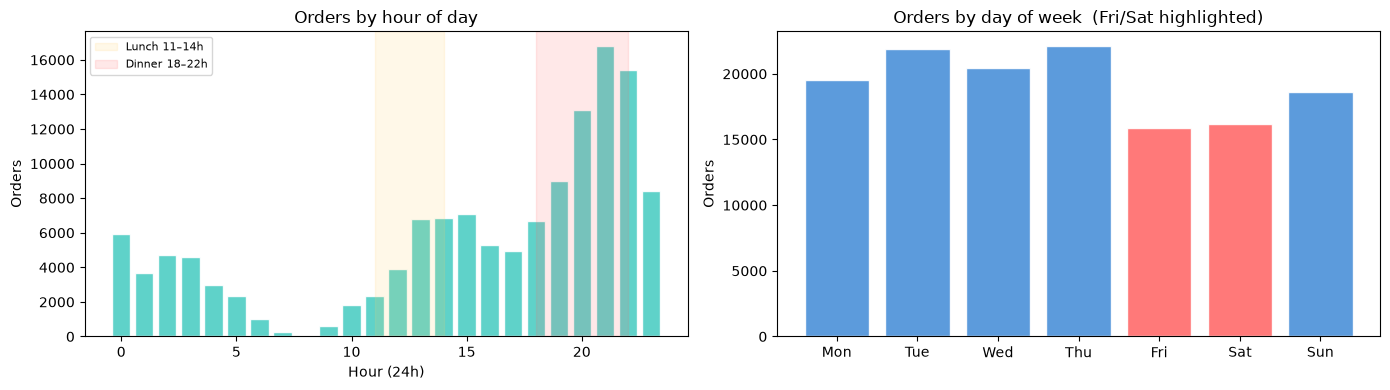

In [ ]:
# ── 5.7  Visualise temporal patterns (validation) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hour of day
hour_counts = orders["order_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color=PAL["teal"], edgecolor="white", alpha=0.9)
axes[0].axvspan(11, 14, alpha=0.15, color=PAL["gold"],  label="Lunch 11–14h")
axes[0].axvspan(18, 22, alpha=0.15, color=PAL["coral"], label="Dinner 18–22h")
axes[0].set_title("Orders by hour of day")
axes[0].set_xlabel("Hour (24h)")
axes[0].set_ylabel("Orders")
axes[0].legend(fontsize=8)

# Day of week
dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_counts = orders["order_dow"].value_counts().sort_index()
colors = [PAL["coral"] if d in [4,5] else PAL["blue"] for d in dow_counts.index]
axes[1].bar(dow_names, dow_counts.values, color=colors, edgecolor="white", alpha=0.9)
axes[1].set_title("Orders by day of week  (Fri/Sat highlighted)")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

In [ ]:
# ── 5.8  Build binary interaction table ──────────────────────────────────────
# Target = 1 if customer ever ordered from vendor (binary, not count)
interactions_binary = (
    orders.drop_duplicates(subset=["customer_id", "vendor_id"])
    [["customer_id", "vendor_id"]]
    .assign(interacted=1)
)

# order_freq: confidence weight for implicit ALS
order_freq = (orders.groupby(["customer_id", "vendor_id"])
              .size()
              .reset_index(name="order_freq"))

interactions_binary = interactions_binary.merge(order_freq,
                                                 on=["customer_id","vendor_id"],
                                                 how="left")

print(f"Binary interaction table: {interactions_binary.shape}")
print(f"Repeat-order pairs: {(order_freq['order_freq'] > 1).sum():,}")
interactions_binary.head()

Binary interaction table: (71071, 4)
Repeat-order pairs: 23,894


,customer_id,vendor_id,interacted,order_freq
0,92PEE24,105,1,4
1,QS68UD8,294,1,1
2,MB7VY5F,83,1,4
3,KDJ951Y,90,1,1
4,BAL0RVT,83,1,4


---
## 6. Engineer Customer Feature Table

In [ ]:
# ── 6.1  Order-level aggregates per customer ─────────────────────────────────
is_rated_col   = "is_rated"   if "is_rated"   in orders.columns else None
is_fav_col     = "is_favorite" if "is_favorite" in orders.columns else None

agg_dict = {
    "vendor_id":          ("n_orders",         "count"),
    "vendor_id":          ("n_unique_vendors",  "nunique"),
    "grand_total_capped": ("avg_order_total",   "mean"),
    "grand_total_capped": ("max_order_total",   "max"),
    "item_count":         ("avg_item_count",    "mean"),
}

cust_stats = orders.groupby("customer_id").agg(
    n_orders         = ("vendor_id",          "count"),
    n_unique_vendors = ("vendor_id",          "nunique"),
    avg_order_total  = ("grand_total_capped", "mean"),
    max_order_total  = ("grand_total_capped", "max"),
    avg_item_count   = ("item_count",         "mean"),
).reset_index()

# Preferred payment mode (modal)
if "payment_mode" in orders.columns:
    pref_pay = (orders.groupby("customer_id")["payment_mode"]
                .agg(lambda x: x.mode()[0] if len(x) else np.nan)
                .reset_index()
                .rename(columns={"payment_mode": "preferred_payment_mode"}))
    cust_stats = cust_stats.merge(pref_pay, on="customer_id", how="left")

# Derived features
cust_stats["vendor_diversity_ratio"] = (cust_stats["n_unique_vendors"]
                                         / cust_stats["n_orders"].clip(lower=1))
cust_stats["is_cold_start"]          = (cust_stats["n_orders"] < 3).astype(int)

# Spending tier  (budget: avg ≤ 10 OMR | mid: 10-25 | premium: > 25)
cust_stats["spending_tier"] = pd.cut(
    cust_stats["avg_order_total"],
    bins   = [0, 10, 25, float("inf")],
    labels = [0, 1, 2],   # 0=budget, 1=mid, 2=premium
).astype("Int64")

print(cust_stats.shape)
cust_stats.head(3)

(27220, 10)


,customer_id,n_orders,n_unique_vendors,avg_order_total,max_order_total,avg_item_count,preferred_payment_mode,vendor_diversity_ratio,is_cold_start,spending_tier
0,000THBA,1,1,29.60,29.6,NaN,2,1.0,1,2
1,002510Y,1,1,13.60,13.6,3.0,2,1.0,1,1
2,005ECL6,2,1,24.35,25.3,4.5,1,0.5,1,1


In [ ]:
# ── 6.2  Customer cuisine profile (TF-IDF tag mean over order history) ─────────
tag_cols = [c for c in vendors.columns if c.startswith("tag_")]
vendor_id_col = "id" if "id" in vendors.columns else vendors.index.name or "vendor_id"

# map vendor_id → tag vector
if vendor_id_col in vendors.columns:
    vtag = vendors.set_index(vendor_id_col)[tag_cols]
else:
    vtag = vendors[tag_cols]
    vtag.index.name = "vendor_id"

# join orders → tag vectors, then mean per customer
cust_tag = (
    orders[["customer_id", "vendor_id"]]
    .merge(vtag.reset_index().rename(columns={vendor_id_col: "vendor_id"}),
           on="vendor_id", how="left")
    .drop(columns=["vendor_id"])
    .groupby("customer_id")[tag_cols]
    .mean()
    .add_prefix("cust_")
    .reset_index()
)

print(f"Customer cuisine profile shape: {cust_tag.shape}")

Customer cuisine profile shape: (27220, 47)


In [ ]:
# ── 6.3  Location aggregates per customer ────────────────────────────────────
loc_agg = (locations.groupby("customer_id")
           .agg(
               n_saved_locations = ("location_type", "count"),
               has_work_address  = ("location_type",
                                     lambda x: int((x == "Work").any())),
           )
           .reset_index())

# ── 6.4  Merge into final customer feature table ─────────────────────────────
customers_feat = (
    customers
    .merge(cust_stats,  on="customer_id", how="left")
    .merge(cust_tag,    on="customer_id", how="left")
    .merge(loc_agg,     on="customer_id", how="left")
)

# Fill customers who have no orders yet (zero-order records)
customers_feat["n_orders"]         = customers_feat["n_orders"].fillna(0)
customers_feat["n_unique_vendors"] = customers_feat["n_unique_vendors"].fillna(0)
customers_feat["is_cold_start"]    = customers_feat["is_cold_start"].fillna(1).astype(int)

# Fill TF-IDF cols with 0 for users with no order history
cust_tag_cols = [c for c in customers_feat.columns if c.startswith("cust_tag_")]
customers_feat[cust_tag_cols] = customers_feat[cust_tag_cols].fillna(0)

print("Customer feature table:")
print(customers_feat.shape)
customers_feat.head(3)

Customer feature table:
(34674, 63)


,customer_id,gender,created_at,updated_at,account_age_days,gender_enc,n_orders,n_unique_vendors,avg_order_total,max_order_total,avg_item_count,preferred_payment_mode,vendor_diversity_ratio,is_cold_start,spending_tier,cust_tag_american,cust_tag_arabic,cust_tag_asian,cust_tag_biryani,cust_tag_breakfast,cust_tag_burgers,cust_tag_cafe,cust_tag_cakes,cust_tag_coffee,cust_tag_crepes,cust_tag_desserts,cust_tag_donuts,cust_tag_free_delivery,cust_tag_fresh_juices,cust_tag_fries,cust_tag_grills,cust_tag_healthy_food,cust_tag_hot_chocolate,cust_tag_hot_dogs,cust_tag_ice_creams,cust_tag_indian,cust_tag_italian,cust_tag_japanese,cust_tag_kebabs,cust_tag_kids_meal,cust_tag_lebanese,cust_tag_mexican,cust_tag_milkshakes,cust_tag_mishkak,cust_tag_mojitos,cust_tag_omani,cust_tag_pancakes,cust_tag_pasta,cust_tag_pizzas,cust_tag_rice,cust_tag_rolls,cust_tag_salads,cust_tag_sandwiches,cust_tag_shawarma,cust_tag_smoothies,cust_tag_soups,cust_tag_steaks,cust_tag_sweets,cust_tag_thai,cust_tag_unknown,cust_tag_waffles,n_saved_locations,has_work_address
0,TCHWPBT,Male,2018-02-07 19:16:23,2018-02-07 19:16:23,754,0,2.0,2.0,6.650000,7.9,1.000000,1.0,1.000000,1,0,0.160960,0.289828,0.000000,0.000000,0.000000,0.134071,0.00000,0.000000,0.000000,0.0,0.294954,0.282425,0.221870,0.000000,0.181243,0.000000,0.000000,0.000000,0.000000,0.00000,0.297885,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.196142,0.000000,0.000000,0.0,0.147270,0.130713,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,3.0,1.0
1,ZGFSYCZ,Male,2018-02-09 12:04:42,2018-02-09 12:04:41,753,0,41.0,20.0,14.814634,63.3,2.527778,1.0,0.487805,0,1,0.073138,0.009022,0.012752,0.026903,0.028574,0.130549,0.03197,0.017247,0.087337,0.0,0.149579,0.017247,0.050955,0.190411,0.023244,0.009022,0.028038,0.096599,0.015346,0.02909,0.023589,0.000000,0.014379,0.013704,0.059861,0.011545,0.112128,0.0,0.0,0.0,0.0,0.0,0.044596,0.041073,0.011076,0.0,0.138291,0.140117,0.126601,0.095438,0.011894,0.0,0.0,0.0,0.0,0.0,15.0,0.0
2,S2ALZFL,Male,2018-03-14 18:31:43,2018-03-14 18:31:42,719,0,6.0,3.0,11.400000,17.9,2.833333,1.0,0.500000,0,1,0.000000,0.096609,0.000000,0.000000,0.158289,0.129914,0.00000,0.000000,0.000000,0.0,0.298831,0.000000,0.237669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.099295,0.264604,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.373825,0.225776,0.000000,0.0,0.137977,0.126660,0.000000,0.000000,0.192033,0.0,0.0,0.0,0.0,0.0,4.0,1.0


---
## 7. Engineer Vendor Feature Table

In [ ]:
# ── 7.1  Order-level aggregates per vendor ───────────────────────────────────
vendor_stats = orders.groupby("vendor_id").agg(
    vendor_n_orders           = ("customer_id", "count"),
    vendor_n_unique_customers = ("customer_id", "nunique"),
    vendor_avg_order_total    = ("grand_total_capped", "mean"),
    vendor_avg_item_count     = ("item_count", "mean"),
).reset_index()

# Log-transform order count to dampen power-law skew
vendor_stats["vendor_log_order_count"] = np.log1p(vendor_stats["vendor_n_orders"])

# Popularity rank (1 = most ordered)
vendor_stats["vendor_popularity_rank"] = (
    vendor_stats["vendor_n_orders"]
    .rank(ascending=False, method="min")
    .astype(int)
)

print(vendor_stats.shape)
vendor_stats.head()

(100, 7)


,vendor_id,vendor_n_orders,vendor_n_unique_customers,vendor_avg_order_total,vendor_avg_item_count,vendor_log_order_count,vendor_popularity_rank
0,4,2134,933,16.094470,3.074093,7.666222,11
1,13,730,293,17.842740,2.098981,6.594413,73
2,20,1583,769,21.149400,2.583106,7.367709,23
3,23,916,444,22.790175,2.483276,6.821107,51
4,28,1522,974,13.000591,3.053824,7.328437,26


In [ ]:
# ── 7.2  Merge stats into cleaned vendor table ────────────────────────────────
vid_col = "id" if "id" in vendors.columns else "vendor_id"

vendors_feat = (
    vendors.rename(columns={vid_col: "vendor_id"})
    .merge(vendor_stats, on="vendor_id", how="left")
)

# Vendors with no orders (true cold-start vendor — shouldn't happen in this dataset)
vendors_feat["vendor_n_orders"]        = vendors_feat["vendor_n_orders"].fillna(0)
vendors_feat["vendor_log_order_count"] = vendors_feat["vendor_log_order_count"].fillna(0)
vendors_feat["is_cold_start_vendor"]   = (vendors_feat["vendor_n_orders"] == 0).astype(int)

print("Vendor feature table:")
print(vendors_feat.shape)
vendors_feat.head(3)

Vendor feature table:
(100, 110)


,vendor_id,authentication_id,latitude,longitude,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,discount_percentage,status,verified,rank,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,friday_from_time1,friday_to_time1,friday_from_time2,friday_to_time2,saturday_from_time1,saturday_to_time1,saturday_from_time2,saturday_to_time2,primary_tags,vendor_tag,vendor_tag_name,created_at,updated_at,vendor_rating_imputed,...,tag_crepes,tag_desserts,tag_donuts,tag_free_delivery,tag_fresh_juices,tag_fries,tag_grills,tag_healthy_food,tag_hot_chocolate,tag_hot_dogs,tag_ice_creams,tag_indian,tag_italian,tag_japanese,tag_kebabs,tag_kids_meal,tag_lebanese,tag_mexican,tag_milkshakes,tag_mishkak,tag_mojitos,tag_omani,tag_pancakes,tag_pasta,tag_pizzas,tag_rice,tag_rolls,tag_salads,tag_sandwiches,tag_shawarma,tag_smoothies,tag_soups,tag_steaks,tag_sweets,tag_thai,tag_unknown,tag_waffles,vcat_2.0,vcat_3.0,delivery_charge_norm,prepration_time_norm,vendor_rating_norm,serving_distance_norm,vendor_n_orders,vendor_n_unique_customers,vendor_avg_order_total,vendor_avg_item_count,vendor_log_order_count,vendor_popularity_rank,is_cold_start_vendor
0,4,118597.0,-0.588596,0.754434,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,1.0,1,11,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,"{""primary_tags"":""4""}","2,4,5,8,91,22,12,24,16,23","Arabic,Breakfast,Burgers,Desserts,Free Deliver...",2018-01-30 14:42:04,2020-04-07 15:12:43,0,...,0.000000,0.213708,0.0,0.283167,0.0,0.0,0.369901,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.473356,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.246831,0.219080,0.369901,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,0,0.0,0.250,0.7500,0.307692,2134,933,16.09447,3.074093,7.666222,11,0
1,13,118608.0,-0.471654,0.744470,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,1.0,1,11,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,"{""primary_tags"":""7""}","4,41,51,34,27,15,24,16,28","Breakfast,Cakes,Crepes,Italian,Pasta,Pizzas,Sa...",2018-05-03 12:32:06,2020-04-05 20:46:03,0,...,0.442359,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.419017,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.291003,0.357532,0.0,0.0,0.218496,0.193931,0.000000,0.0,0.304096,0.0,0.0,0.0,0.0,0.0,1,0,1.0,0.225,0.9375,0.230769,730,293,17.84274,2.098981,6.594413,73,0
2,20,118616.0,-0.407527,0.643681,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,1.0,1,1,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,"{""primary_tags"":""71""}","4,8,91,10","Breakfast,Desserts,Free Delivery,Indian",2018-05-04 22:28:22,2020-04-07 16:35:55,0,...,0.000000,0.360934,0.0,0.478245,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.642098,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,0,0.0,0.350,0.8125,0.461538,1583,769,21.14940,2.583106,7.367709,23,0


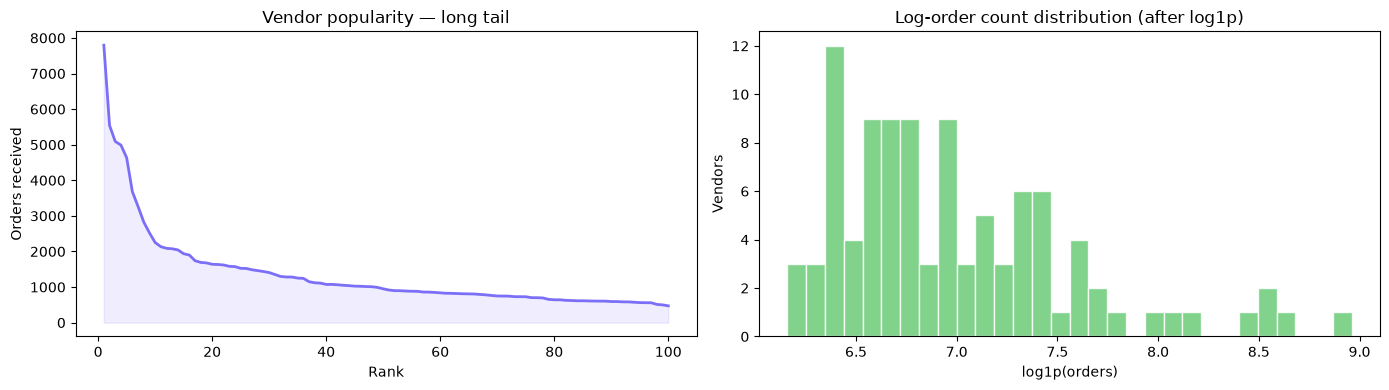

In [ ]:
# ── 7.3  Visualise vendor popularity (validation) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

opv = vendor_stats["vendor_n_orders"].sort_values(ascending=False)
axes[0].plot(range(1, len(opv)+1), opv.values, color=PAL["violet"], lw=2)
axes[0].fill_between(range(1, len(opv)+1), opv.values, alpha=0.12, color=PAL["violet"])
axes[0].set_title("Vendor popularity — long tail")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Orders received")

axes[1].hist(vendor_stats["vendor_log_order_count"], bins=30,
             color=PAL["green"], edgecolor="white", alpha=0.85)
axes[1].set_title("Log-order count distribution (after log1p)")
axes[1].set_xlabel("log1p(orders)")
axes[1].set_ylabel("Vendors")

plt.tight_layout()
plt.show()

---
## 8. Build Interaction Feature Table

This is the key table fed to the GBM combiner.
Each row is one **(customer_id × location_number × vendor_id)** candidate from `train_full.csv`.

Steps:
1. Parse the composite key `CID X LOC_NUM X VENDOR`
2. Join customer location coordinates
3. Join vendor coordinates
4. Compute haversine distance + `within_serving_distance` binary flag
5. Join all customer and vendor features
6. Attach binary target (did the customer ever order from this vendor?)

> **Class imbalance note:** Positive rate ≈ 0.1–0.5 %; imbalance ratio ≈ 200–1000:1.
> Do NOT oversample before train/val split. Use `scale_pos_weight` in the GBM combiner.

In [ ]:
train_full.head()

,customer_id,gender,status_x,verified_x,created_at_x,updated_at_x,location_number,location_type,latitude_x,longitude_x,id,authentication_id,latitude_y,longitude_y,vendor_category_en,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,commission,is_akeed_delivering,discount_percentage,status_y,verified_y,rank,language,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,friday_from_time1,friday_to_time1,friday_from_time2,friday_to_time2,saturday_from_time1,saturday_to_time1,saturday_from_time2,saturday_to_time2,primary_tags,open_close_flags,vendor_tag,vendor_tag_name,one_click_vendor,country_id,city_id,created_at_y,updated_at_y,device_type,display_orders,location_number_obj,id_obj,CID X LOC_NUM X VENDOR,target
0,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,4,118597.0,-0.5884,0.7544,Restaurants,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,00:00:00,00:30:00,10:00:00,23:59:00,"{""primary_tags"":""4""}",1.0,"2,4,5,8,91,22,12,24,16,23","Arabic,Breakfast,Burgers,Desserts,Free Deliver...",Y,1.0,1.0,2018-01-30 14:42:04,2020-04-07 15:12:43,3,1,0,4,TCHWPBT X 0 X 4,0
1,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,13,118608.0,-0.4717,0.7446,Restaurants,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,Yes,0.0,1.0,1,11,EN,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,"{""primary_tags"":""7""}",1.0,"4,41,51,34,27,15,24,16,28","Breakfast,Cakes,Crepes,Italian,Pasta,Pizzas,Sa...",Y,1.0,1.0,2018-05-03 12:32:06,2020-04-05 20:46:03,3,1,0,13,TCHWPBT X 0 X 13,0
2,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,20,118616.0,-0.4075,0.6436,Restaurants,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,Yes,0.0,1.0,1,1,EN,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,"{""primary_tags"":""71""}",1.0,"4,8,91,10","Breakfast,Desserts,Free Delivery,Indian",Y,1.0,1.0,2018-05-04 22:28:22,2020-04-07 16:35:55,3,1,0,20,TCHWPBT X 0 X 20,0
3,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,23,118619.0,-0.5854,0.7540,Restaurants,2.0,0.0,5.0,1.0,10:59AM-10:30PM,-,16,0.0,Yes,0.0,1.0,1,11,EN,4.5,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:30:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,09:00:00,23:45:00,NaN,NaN,"{""primary_tags"":""46""}",1.0,"5,8,30,24","Burgers,Desserts,Fries,Salads",Y,1.0,1.0,2018-05-06 19:20:48,2020-04-02 00:56:17,3,1,0,23,TCHWPBT X 0 X 23,0
4,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,28,118624.0,0.4807,0.5527,Restaurants,2.0,0.7,15.0,1.0,11:00AM-11:45PM,-,10,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,00:30:00,11:00:00,23:59:00,00:01:00,01:30:00,17:45:00,23:59:00,00:01:00,01:30:00,17:45:00,23:59:00,"{""primary_tags"":""32""}",1.0,5,Burgers,Y,1.0,1.0,2018-05-17 22:12:38,2020-04-05 15:57:41,3,1,0,28,TCHWPBT X 0 X 28,0


In [ ]:
# ── 8.1  Parse composite key ─────────────────────────────────────────────────
candidates = train_full.copy()

key_split = candidates["CID X LOC_NUM X VENDOR"].str.split(" X ", expand=True)
candidates["customer_id"]     = key_split[0]
candidates["location_number"] = pd.to_numeric(key_split[1], errors="coerce")
candidates["vendor_id"]       = pd.to_numeric(key_split[2], errors="coerce")

print("Candidate table:", candidates.shape)
candidates[["customer_id","location_number","vendor_id"]].head()

Candidate table: (5802400, 74)


,customer_id,location_number,vendor_id
0,TCHWPBT,0,4
1,TCHWPBT,0,13
2,TCHWPBT,0,20
3,TCHWPBT,0,23
4,TCHWPBT,0,28


In [ ]:
# ── 8.2  Join customer location (lat/lon) ────────────────────────────────────
# Critical: key = (customer_id, location_number) — NOT just customer_id
loc_coords = locations[["customer_id","location_number",
                          "latitude","longitude",
                          "location_type_enc","n_saved_locations"]].copy()

candidates = candidates.merge(loc_coords,
                               on=["customer_id","location_number"],
                               how="left")

# ── 8.3  Join vendor coordinates ──────────────────────────────────────────────
vend_coords = vendors_feat[
    [
        "vendor_id",
        "latitude",
        "longitude",
        "serving_distance",
        "delivery_charge",
        "prepration_time",
        "vendor_rating",
        "vendor_n_orders",
        "vendor_log_order_count",
        "is_cold_start_vendor",
        "is_open"
    ]
].copy()

vend_coords = vend_coords.rename(
    columns={
        "latitude": "vendor_lat",
        "longitude": "vendor_lon",
        "serving_distance": "vendor_serving_distance",
        "delivery_charge": "vendor_delivery_charge",
        "prepration_time": "vendor_prep_time",
        "vendor_rating": "vendor_rating_feat",
        "is_open": "vendor_is_open"
    }
)

candidates = candidates.merge(
    vend_coords,
    on="vendor_id",
    how="left"
)

print("After geo joins:", candidates.shape)

After geo joins: (5802400, 88)


In [ ]:
# ── 8.4  Compute haversine distance ──────────────────────────────────────────
print("Computing haversine distances...")
candidates["distance_km"] = haversine_series(
    candidates["latitude"].values,
    candidates["longitude"].values,
    candidates["vendor_lat"].values,
    candidates["vendor_lon"].values,
)

# Cap at 50 km (removes corrupted 9,416 km outliers as features)
# candidates["distance_km_capped"] = candidates["distance_km"].clip(upper=50.0)

# Hard filter flag: is the customer within the vendor's delivery radius?
candidates["within_serving_distance"] = (
    candidates["distance_km"] <= candidates["serving_distance"]
).astype(int)

print("Distance stats (capped at 50 km):")
# print(candidates["distance_km_capped"].describe().round(2))
print(f"\nWithin serving distance: {candidates['within_serving_distance'].mean()*100:.1f}%")

Computing haversine distances...
Distance stats (capped at 50 km):

Within serving distance: 2.2%


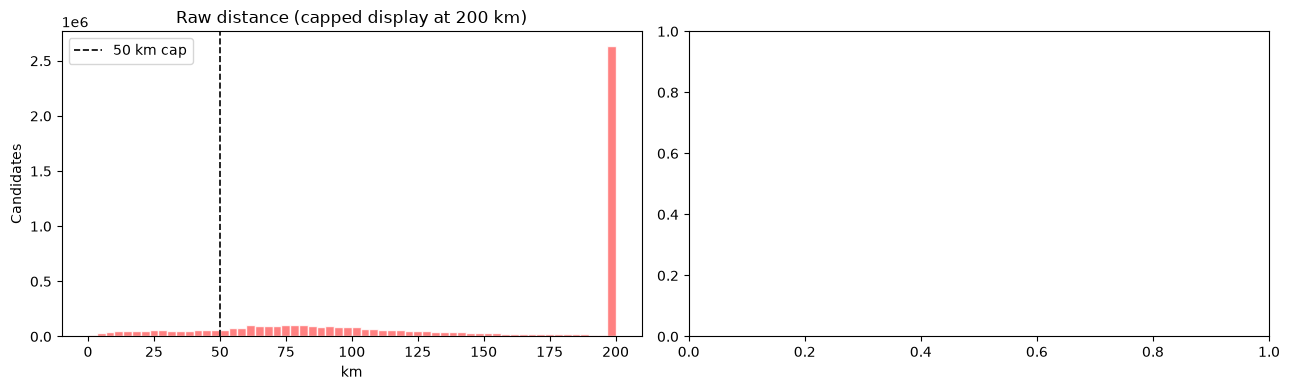

In [ ]:
# ── 8.5  Visualise distance distribution (validation) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(candidates["distance_km"].dropna().clip(upper=200),
             bins=60, color=PAL["coral"], edgecolor="white", alpha=0.85)
axes[0].set_title("Raw distance (capped display at 200 km)")
axes[0].set_xlabel("km")
axes[0].set_ylabel("Candidates")
axes[0].axvline(50, color="black", lw=1.2, ls="--", label="50 km cap")
axes[0].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── 8.6  Attach binary target ─────────────────────────────────────────────────
ordered_pairs = set(zip(orders["customer_id"], orders["vendor_id"]))
candidates["target"] = candidates.apply(
    lambda r: 1 if (r["customer_id"], r["vendor_id"]) in ordered_pairs else 0,
    axis=1
)

n_pos = candidates["target"].sum()
n_tot = len(candidates)
pos_rate = n_pos / n_tot * 100
print(f"Target distribution:")
print(f"  Positive: {n_pos:,}  ({pos_rate:.3f}%)")
print(f"  Negative: {n_tot - n_pos:,}  ({100 - pos_rate:.3f}%)")
print(f"  Imbalance ratio: ~{int(n_tot / max(n_pos,1)):,} : 1")

Target distribution:
  Positive: 181,183  (3.123%)
  Negative: 5,621,217  (96.877%)
  Imbalance ratio: ~32 : 1


In [ ]:
# ── 8.7  Join customer + vendor feature tables ───────────────────────────────
CUST_FEAT_COLS = [
    "customer_id", "gender_enc", "account_age_days",
    "n_orders", "n_unique_vendors", "vendor_diversity_ratio",
    "is_cold_start", "avg_order_total", "spending_tier",
    "n_saved_locations",
] + [c for c in customers_feat.columns if c.startswith("cust_tag_")]

VEND_FEAT_COLS = [
    "vendor_id",
    "vendor_rating", "vendor_rating_imputed",
    "serving_distance_norm", "delivery_charge_norm", "prepration_time_norm",
    "discount_percentage", "rank", "is_akeed_delivering", "one_click_vendor",
    "vendor_n_orders", "vendor_log_order_count",
    "vendor_popularity_rank", "is_cold_start_vendor",
] + [c for c in vendors_feat.columns if c.startswith("tag_")]    + [c for c in vendors_feat.columns if c.startswith("vcat_")]

avail_cust = [c for c in CUST_FEAT_COLS if c in customers_feat.columns]
avail_vend = [c for c in VEND_FEAT_COLS if c in vendors_feat.columns]

interactions_feat = (
    candidates
    .merge(customers_feat[avail_cust], on="customer_id", how="left")
    .merge(vendors_feat[avail_vend],   on="vendor_id",   how="left", suffixes=("","_vf"))
)

print("Final interaction feature table:")
print(interactions_feat.shape)
interactions_feat.head(3)

Final interaction feature table:
(5821300, 204)


,customer_id,gender,status_x,verified_x,created_at_x,updated_at_x,location_number,location_type,latitude_x,longitude_x,id,authentication_id,latitude_y,longitude_y,vendor_category_en,vendor_category_id,delivery_charge,serving_distance,is_open,OpeningTime,OpeningTime2,prepration_time,commission,is_akeed_delivering,discount_percentage,status_y,verified_y,rank,language,vendor_rating,sunday_from_time1,sunday_to_time1,sunday_from_time2,sunday_to_time2,monday_from_time1,monday_to_time1,monday_from_time2,monday_to_time2,tuesday_from_time1,tuesday_to_time1,tuesday_from_time2,tuesday_to_time2,wednesday_from_time1,wednesday_to_time1,wednesday_from_time2,wednesday_to_time2,thursday_from_time1,thursday_to_time1,thursday_from_time2,thursday_to_time2,...,vendor_popularity_rank,is_cold_start_vendor_vf,tag_american,tag_arabic,tag_asian,tag_biryani,tag_breakfast,tag_burgers,tag_cafe,tag_cakes,tag_coffee,tag_crepes,tag_desserts,tag_donuts,tag_free_delivery,tag_fresh_juices,tag_fries,tag_grills,tag_healthy_food,tag_hot_chocolate,tag_hot_dogs,tag_ice_creams,tag_indian,tag_italian,tag_japanese,tag_kebabs,tag_kids_meal,tag_lebanese,tag_mexican,tag_milkshakes,tag_mishkak,tag_mojitos,tag_omani,tag_pancakes,tag_pasta,tag_pizzas,tag_rice,tag_rolls,tag_salads,tag_sandwiches,tag_shawarma,tag_smoothies,tag_soups,tag_steaks,tag_sweets,tag_thai,tag_unknown,tag_waffles,vcat_2.0,vcat_3.0
0,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,4,118597.0,-0.5884,0.7544,Restaurants,2.0,0.0,6.0,1.0,11:00AM-11:30PM,-,15,0.0,Yes,0.0,1.0,1,11,EN,4.4,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,00:00:00,00:30:00,08:00:00,23:59:00,...,11,0,0.0,0.369901,0.0,0.0,0.283167,0.224708,0.0,0.000000,0.0,0.000000,0.213708,0.0,0.283167,0.0,0.0,0.369901,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.473356,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.246831,0.219080,0.369901,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,0
1,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,13,118608.0,-0.4717,0.7446,Restaurants,2.0,0.7,5.0,1.0,08:30AM-10:30PM,-,14,0.0,Yes,0.0,1.0,1,11,EN,4.7,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,23:59:00,00:00:00,01:30:00,08:00:00,19:30:00,00:00:00,01:30:00,08:00:00,19:30:00,...,73,0,0.0,0.000000,0.0,0.0,0.250661,0.000000,0.0,0.419017,0.0,0.442359,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.419017,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.291003,0.357532,0.0,0.0,0.218496,0.193931,0.000000,0.0,0.304096,0.0,0.0,0.0,0.0,0.0,1,0
2,TCHWPBT,Male,1,1,2018-02-07 19:16:23,2018-02-07 19:16:23,0,Work,-96.44,-67.2,20,118616.0,-0.4075,0.6436,Restaurants,2.0,0.0,8.0,1.0,08:00AM-10:45PM,-,19,0.0,Yes,0.0,1.0,1,1,EN,4.5,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,08:00:00,22:45:00,NaN,NaN,...,23,0,0.0,0.000000,0.0,0.0,0.478245,0.000000,0.0,0.000000,0.0,0.000000,0.360934,0.0,0.478245,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.642098,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,0


---
## 9. Feature Table Validation

In [ ]:
vendors_df["one_click_vendor"].unique()

<StringArray>
['Y']
Length: 1, dtype: str

In [ ]:
# ── Null counts check ─────────────────────────────────────────────────────────
print("=== NULL COUNTS SUMMARY ===\n")

for name, df in [
    ("customers_features",    customers_feat),
    ("vendors_features",      vendors_feat),
    ("interactions_features", interactions_feat),
]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    pct   = (nulls / len(df) * 100).round(1)
    print(f"--- {name} ({df.shape}) ---")
    if nulls.empty:
        print("  ✓ No nulls")
    else:
        for col in nulls.index:
            print(f"  {col:<45} {nulls[col]:>6,} ({pct[col]}%)")
    print()

=== NULL COUNTS SUMMARY ===

--- customers_features ((34674, 63)) ---
  avg_order_total                                8,024 (23.1%)
  max_order_total                                8,024 (23.1%)
  avg_item_count                                 8,501 (24.5%)
  preferred_payment_mode                         8,024 (23.1%)
  vendor_diversity_ratio                         8,024 (23.1%)
  spending_tier                                  8,024 (23.1%)
  n_saved_locations                                  1 (0.0%)
  has_work_address                                   1 (0.0%)

--- vendors_features ((100, 110)) ---
  OpeningTime                                        9 (9.0%)
  OpeningTime2                                       9 (9.0%)
  sunday_from_time1                                  1 (1.0%)
  sunday_to_time1                                    1 (1.0%)
  sunday_from_time2                                 58 (58.0%)
  sunday_to_time2                                   58 (58.0%)
  monday_from_t

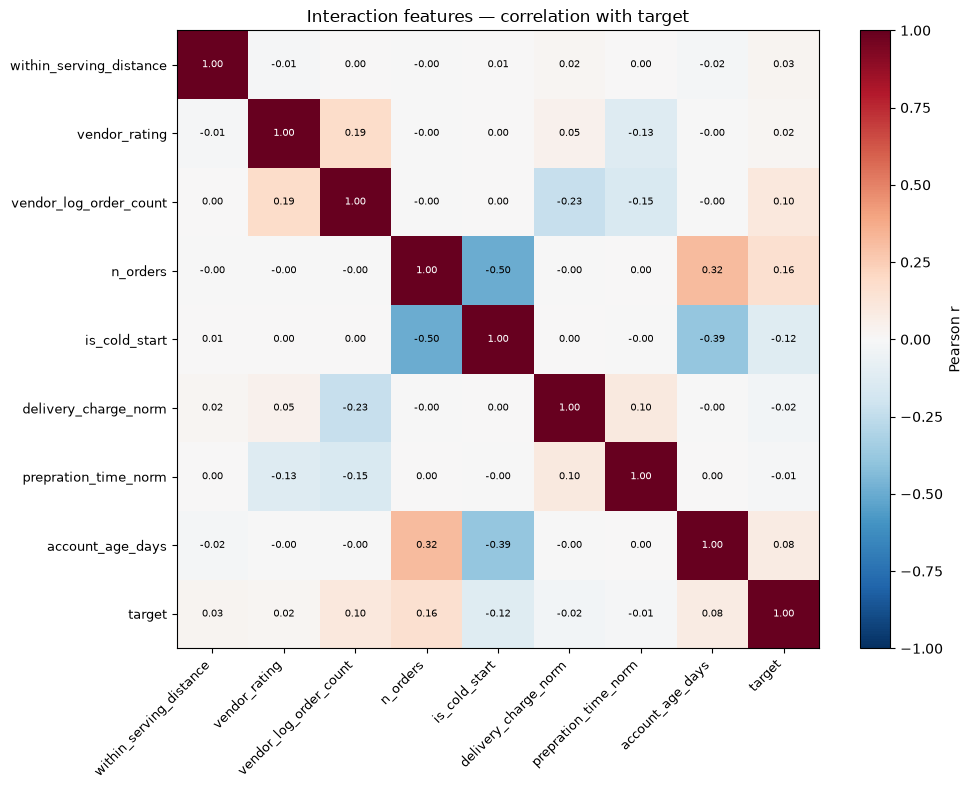

In [ ]:
# ── Correlation heatmap on interaction numeric features ───────────────────────
CORR_COLS = [
    "distance_km_capped", "within_serving_distance",
    "vendor_rating", "vendor_log_order_count",
    "n_orders", "is_cold_start",
    "delivery_charge_norm", "prepration_time_norm",
    "account_age_days", "target",
]
avail = [c for c in CORR_COLS if c in interactions_feat.columns]
corr  = interactions_feat[avail].copy()
for c in avail:
    corr[c] = pd.to_numeric(corr[c], errors="coerce")
corr_matrix = corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(avail))); ax.set_xticklabels(avail, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(avail))); ax.set_yticklabels(avail, fontsize=9)
for i in range(len(avail)):
    for j in range(len(avail)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr_matrix.iloc[i,j]) > 0.5 else "black")
ax.set_title("Interaction features — correlation with target")
plt.tight_layout()
plt.show()

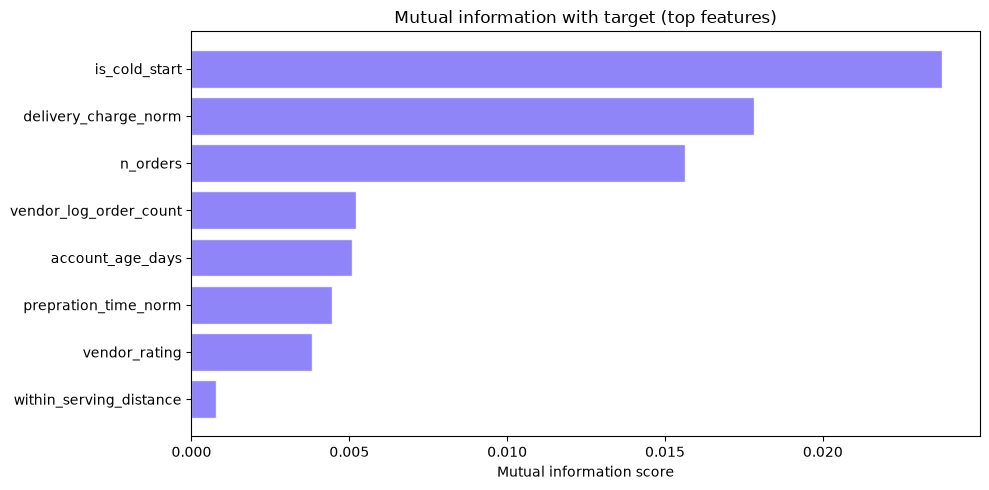

                feature       MI
          is_cold_start 0.023788
   delivery_charge_norm 0.017816
               n_orders 0.015629
 vendor_log_order_count 0.005222
       account_age_days 0.005083
   prepration_time_norm 0.004452
          vendor_rating 0.003826
within_serving_distance 0.000790


In [ ]:
# ── Feature importance preview (mutual information proxy) ─────────────────────
from sklearn.feature_selection import mutual_info_classif

MI_COLS = [c for c in avail if c != "target"]
X_mi = interactions_feat[MI_COLS].fillna(0)
y_mi = interactions_feat["target"].fillna(0)

# Subsample for speed if large
if len(X_mi) > 100_000:
    idx = np.random.default_rng(42).choice(len(X_mi), 100_000, replace=False)
    X_mi, y_mi = X_mi.iloc[idx], y_mi.iloc[idx]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features="auto", random_state=42)
mi_df = (pd.DataFrame({"feature": MI_COLS, "MI": mi_scores})
         .sort_values("MI", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mi_df["feature"][::-1], mi_df["MI"][::-1],
        color=PAL["violet"], edgecolor="white", alpha=0.85)
ax.set_title("Mutual information with target (top features)")
ax.set_xlabel("Mutual information score")
plt.tight_layout()
plt.show()
print(mi_df.to_string(index=False))

---
## 10. Save Feature Tables

In [ ]:
customers_feat.to_parquet(OUTPUT_DIR / "customers_features.parquet", engine="fastparquet" ,index=False)
vendors_feat.to_parquet(OUTPUT_DIR   / "vendors_features.parquet",   engine="fastparquet" ,index=False)
interactions_feat.to_parquet(OUTPUT_DIR / "interactions_features.parquet", engine="fastparquet", index=False)

print("Saved to:", OUTPUT_DIR)
print(f"  customers_features.parquet     → {customers_feat.shape}")
print(f"  vendors_features.parquet       → {vendors_feat.shape}")
print(f"  interactions_features.parquet  → {interactions_feat.shape}")
print()
print("Feature tables are ready for:")
print("  • Random / popularity baseline  (vendor_log_order_count, vendor_rating)")
print("  • Content-based model           (tag_* + cust_tag_* cosine similarity)")
print("  • CF / implicit ALS             (interactions_binary + order_freq)")
print("  • Geo + rules filter            (distance_km_capped, within_serving_distance)")
print("  • GBM stacking combiner         (all above + is_cold_start + spending_tier)")

Saved to: d:\ITI Materials\Projects\restaurant-recommender-system\data\processed
  customers_features.parquet     → (34674, 63)
  vendors_features.parquet       → (100, 110)
  interactions_features.parquet  → (5821300, 204)

Feature tables are ready for:
  • Random / popularity baseline  (vendor_log_order_count, vendor_rating)
  • Content-based model           (tag_* + cust_tag_* cosine similarity)
  • CF / implicit ALS             (interactions_binary + order_freq)
  • Geo + rules filter            (distance_km_capped, within_serving_distance)
  • GBM stacking combiner         (all above + is_cold_start + spending_tier)
